In [1]:

# from concurrent.futures import ProcessPoolExecutor

# import scipy.special as sc
# from scipy.integrate import quad_vec
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.special import gammaln
# from scipy import stats

# # =====================================================================
# # 1. EMPIRICAL SAMPLING FOR THE CONTINUOUS SPECTRUM
# # =====================================================================

# SIGMA = 0.2
# THETA_INIT = 0.2
# # Bump width τ = TAU_SCALE * sqrt(W). Peak stays at Z = X²; TAU_SCALE < 1 => sharper (narrower) bump.
# TAU_SCALE = 0.2
# # Policy / networks observe X of shape (n, X_DIM); column 0 is task difficulty u ~ U(0.5,1.5),
# # remaining columns are random covariates (reward depends only on u for scalar θ).
# X_DIM = 16  # change here; nets use in_features=X_DIM (re-run setup + training cells after)

# # def sample_data(n_problems, n_generations, sigma=SIGMA, theta_init=THETA_INIT):
# #     if X_DIM < 1:
# #         raise ValueError("X_DIM must be >= 1")
# #     x0 = np.random.uniform(0.5, 1.5, n_problems)
# #     if X_DIM == 1:
# #         X = x0.reshape(-1, 1)
# #     else:
# #         extras = np.random.standard_normal((n_problems, X_DIM - 1))
# #         X = np.column_stack([x0, extras])
# #     W = 0.07 - 0.04 * x0
# #     Z = np.random.normal(loc=theta_init * x0[:, None], scale=sigma, size=(n_problems, n_generations))

# #     tau = (TAU_SCALE * np.sqrt(W))[:, np.newaxis]
# #     target = (x0**2)[:, np.newaxis]
# #     Y = np.exp(-((Z - target) ** 2) / (2 * tau**2))

# #     score = ((Z - theta_init * x0[:, None]) * x0[:, None]) / sigma**2
# #     return X, Z, Y, score

# def sample_data(n_problems, n_generations, target_k=None, sigma=SIGMA, theta_init=THETA_INIT):
#     if X_DIM < 1:
#         raise ValueError("X_DIM must be >= 1")
#     x0 = np.random.uniform(0.5, 1.5, n_problems)
    
#     if X_DIM == 1:
#         X = x0.reshape(-1, 1)
#     else:
#         extras = np.random.standard_normal((n_problems, X_DIM - 1))
#         X = np.column_stack([x0, extras])
        
#     W = 0.07 - 0.04 * x0
#     Z = np.random.normal(loc=theta_init * x0[:, None], scale=sigma, size=(n_problems, n_generations))

#     tau = (TAU_SCALE * np.sqrt(W))[:, np.newaxis]
#     target = (x0**2)[:, np.newaxis]
#     Y = np.exp(-((Z - target) ** 2) / (2 * tau**2))

#     score = ((Z - theta_init * x0[:, None]) * x0[:, None]) / sigma**2
    
#     # =================================================================
#     # EXACT CONTINUOUS ORACLE ADVANTAGE (Vectorized Riemann)
#     # =================================================================
#     true_adv = None
#     if target_k is not None:
#         # Integration grid (2000 slices is functionally infinite precision for RL)
#         grid_size = 2000
#         dz = 1.0 / grid_size
#         z_grid = np.linspace(dz/2, 1.0 - dz/2, grid_size)
        
#         # Broadcasting setup
#         mu_Z = (theta_init * x0)[:, np.newaxis]
#         tau_2d = tau
#         target_2d = target
        
#         # Analytical CCDF: S(z) = P(Y > z)
#         offset = tau_2d * np.sqrt(-2.0 * np.log(z_grid))
#         z_up = (target_2d + offset - mu_Z) / sigma
#         z_dn = (target_2d - offset - mu_Z) / sigma
        
#         S_z = stats.norm.cdf(z_up) - stats.norm.cdf(z_dn) # Shape: (n_problems, grid_size)
        
#         # Suppressor: (1 - S(z))^(k-1)
#         suppressor = (1.0 - S_z) ** (target_k - 1)
        
#         # 3D broadcasting for the batch
#         Y_3d = Y[:, :, np.newaxis]
#         z_3d = z_grid[np.newaxis, np.newaxis, :]
#         indicator = (Y_3d > z_3d).astype(np.float64)
        
#         supp_3d = suppressor[:, np.newaxis, :]
#         S_z_3d = S_z[:, np.newaxis, :]
        
#         # Integrate: sum( (1 - S_z)^(k-1) * (I(Y>z) - S_z) * dz )
#         integrand = supp_3d * (indicator - S_z_3d)
#         true_adv = np.sum(integrand * dz, axis=-1)
        
#     return X, Z, Y, score, true_adv


# def compute_analytical_curves(
#     thetas,
#     k_values,
#     sigma=SIGMA,
#     tau_scale=TAU_SCALE,
#     n_x=256,
#     N_oversample=4096, # The size of the "pool" to draw from
#     seed=42,
#     **kwargs # Absorbs legacy n_jobs/n_mc arguments without breaking plots
# ):
#     """
#     Computes E[max@k] curves using a fast Empirical U-Statistic.
#     Oversamples N points, sorts them, and applies exact log-combinatorial weights.
#     """
#     thetas = np.asarray(thetas, dtype=np.float64)
#     n_thetas = len(thetas)
    
#     # 1. Setup Environment
#     X = np.linspace(0.5, 1.5, n_x)
#     W = 0.07 - 0.04 * X
#     tau = tau_scale * np.sqrt(W)
#     target = X**2
    
#     # 2. Precompute Combinatorial Weights for all k
#     weights = {}
#     for k in k_values:
#         w = np.zeros(N_oversample)
#         if k == 1:
#             # Special case for k=1 to avoid 0-division/logic issues
#             w[:] = 1.0 / N_oversample
#         else:
#             i = np.arange(k - 1, N_oversample)
#             # log(nCr) = gammaln(n+1) - gammaln(r+1) - gammaln(n-r+1)
#             log_num = gammaln(i + 1) - gammaln(k) - gammaln(i - k + 2)
#             log_den = gammaln(N_oversample + 1) - gammaln(k + 1) - gammaln(N_oversample - k + 1)
#             w[k - 1:] = np.exp(log_num - log_den)
            
#         weights[k] = w

#     # 3. Fix the random noise (Reparameterization Trick for smooth curves)
#     rng = np.random.default_rng(seed)
#     epsilon = rng.standard_normal((n_x, N_oversample))
    
#     expected_rewards = {k: np.zeros(n_thetas) for k in k_values}
    
#     # 4. Batch Process to maximize cache hits and prevent memory overflow
#     # A chunk of 50 takes ~400MB of RAM for the 3D matrices
#     chunk_size = 50
#     for i in range(0, n_thetas, chunk_size):
#         theta_chunk = thetas[i : i + chunk_size] # Shape: (C,)
        
#         # Reshape for broadcasting: 
#         # theta -> (C, 1, 1), X -> (1, n_x, 1), epsilon -> (1, n_x, N)
#         theta_3d = theta_chunk[:, None, None]
#         X_3d = X[None, :, None]
#         epsilon_3d = epsilon[None, :, :]
#         target_3d = target[None, :, None]
#         tau_3d = tau[None, :, None]
        
#         # Z = (theta * X) + (sigma * epsilon)
#         Z = (theta_3d * X_3d) + (sigma * epsilon_3d)
        
#         # Calculate Reward Y
#         Y = np.exp(-((Z - target_3d)**2) / (2 * tau_3d**2))
        
#         # Sort rewards along the N dimension (axis=-1)
#         # NumPy's quicksort handles this almost instantly
#         Y_sorted = np.sort(Y, axis=-1)
        
#         # 5. Apply weights for each k
#         for k in k_values:
#             # Dot product along the N_oversample dimension
#             # Shape goes from (C, n_x, N) @ (N,) -> (C, n_x)
#             E_max_k_X = Y_sorted @ weights[k]
            
#             # Average over the X dimension (axis=1) and store
#             expected_rewards[k][i : i + chunk_size] = np.mean(E_max_k_X, axis=1)
            
#     return expected_rewards



# # =====================================================================
# # 2. COMPUTE THE CURVES
# thetas = np.linspace(0.0, 2.0, 200)
# k_values = [1, 4, 8, 16, 32, 64]
# k_to_best_theta = {}

# # results = compute_empirical_curves(thetas, k_values, N=5000)
# results = compute_analytical_curves(
#     thetas,
#     k_values,
#     sigma=0.2,
#     n_x=256,
#     n_jobs=8,
# )

# # =====================================================================
# # 3. PLOT THE RESULTS
# # =====================================================================
# plt.figure(figsize=(10, 6))
# n_k = len(k_values)
# _base_cmap = plt.cm.tab20 if n_k > 10 else plt.cm.tab10
# colors = _base_cmap(np.linspace(0, 1, n_k, endpoint=False))

# for idx, k in enumerate(k_values):
#     rewards = results[k]
    
#     # Find the peak
#     best_idx = np.argmax(rewards)
#     best_theta = thetas[best_idx]
#     k_to_best_theta[k] = best_theta
#     max_reward = rewards[best_idx]
    
#     plt.plot(thetas, rewards, label=f'k = {k:<2} (θ* = {best_theta:.2f})', 
#              color=colors[idx], linewidth=2.5)
    
#     # Mark the peak
#     plt.plot(best_theta, max_reward, marker='o', markersize=8, color=colors[idx])

# plt.title("Optimal parameter θ* for Different Max@k Objectives (Gaussian bump reward)", 
#           fontsize=14, pad=15)
# plt.xlabel("Policy Parameter (θ)", fontsize=12)
# plt.ylabel("Expected Max@k Reward", fontsize=12)

# plt.axvspan(0.5, 1.5, color='gray', alpha=0.1, label='Spectrum of Target Difficulties')
# plt.legend(fontsize=11, loc='upper left')
# plt.grid(True, alpha=0.3)
# plt.ylim(0, 1.05)
# plt.xlim(0.0, 2.0)
# plt.tight_layout()

# plt.show()

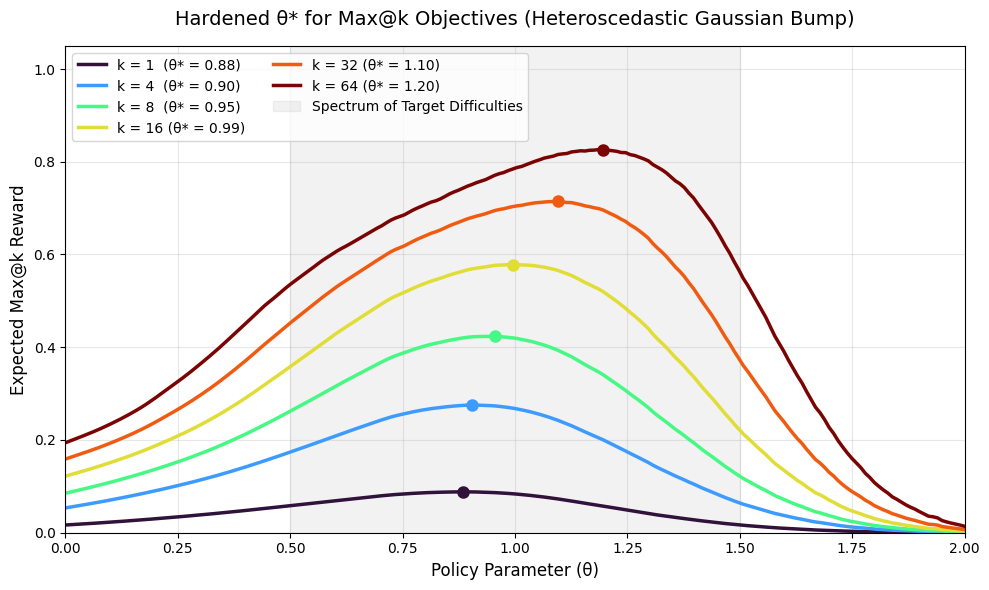

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaln
from scipy import stats

# =====================================================================
# 1. HARD-MODE EMPIRICAL SAMPLING
# =====================================================================

SIGMA_BASE = 0.2
THETA_INIT = 0.2
X_DIM = 16 

def sample_data(n_problems, n_generations, target_k=None, sigma_base=SIGMA_BASE, theta_init=THETA_INIT):
    if X_DIM < 1:
        raise ValueError("X_DIM must be >= 1")
    
    # x0 is the only influential feature for the reward distribution
    x0 = np.random.uniform(0.5, 1.5, n_problems)
    if X_DIM == 1:
        X = x0.reshape(-1, 1)
    else:
        extras = np.random.standard_normal((n_problems, X_DIM - 1))
        X = np.column_stack([x0, extras])

    # 1. NON-LINEAR TARGET: Prevents easy quadratic amortization
    target = (x0**2) + 0.1 * np.sin(10 * x0)
    
    # 2. HETEROSCEDASTIC NOISE: Sigma scales with x0
    sigma = sigma_base * (1.0 + 0.5 * (x0 - 0.5)) 
    
    # 3. SHARPENING BUMP: Tau (precision) narrows as x0 increases
    # This creates the "sparsity" that makes Categorical binning difficult
    tau_val = 0.05 * (1.55 - x0)
    
    Z = np.random.normal(
        loc=theta_init * x0[:, None], 
        scale=sigma[:, np.newaxis], 
        size=(n_problems, n_generations)
    )

    Y = np.exp(-((Z - target[:, np.newaxis]) ** 2) / (2 * tau_val[:, np.newaxis]**2))
    score = ((Z - theta_init * x0[:, None]) * x0[:, None]) / (sigma[:, np.newaxis]**2)
    
    # EXACT CONTINUOUS ORACLE ADVANTAGE (Vectorized Riemann)
    true_adv = None
    if target_k is not None:
        grid_size = 2000
        dz = 1.0 / grid_size
        z_grid = np.linspace(dz/2, 1.0 - dz/2, grid_size)
        
        # S(z) = P(Y > z) logic using the hardened parameters
        # offset = tau * sqrt(-2 * log(z))
        offset = tau_val[:, np.newaxis] * np.sqrt(-2.0 * np.log(z_grid))
        z_up = (target[:, np.newaxis] + offset - (theta_init * x0[:, np.newaxis])) / sigma[:, np.newaxis]
        z_dn = (target[:, np.newaxis] - offset - (theta_init * x0[:, np.newaxis])) / sigma[:, np.newaxis]
        
        S_z = stats.norm.cdf(z_up) - stats.norm.cdf(z_dn)
        suppressor = (1.0 - S_z) ** (target_k - 1)
        
        indicator = (Y[:, :, np.newaxis] > z_grid[np.newaxis, np.newaxis, :]).astype(np.float64)
        integrand = suppressor[:, np.newaxis, :] * (indicator - S_z[:, np.newaxis, :])
        true_adv = np.sum(integrand * dz, axis=-1)
        
    return X, Z, Y, score, true_adv


# =====================================================================
# 2. ANALYTICAL CURVE GENERATION (HARD-MODE)
# =====================================================================

def compute_analytical_curves(
    thetas,
    k_values,
    sigma_base=SIGMA_BASE,
    n_x=256,
    N_oversample=4096,
    seed=42,
    **kwargs
):
    thetas = np.asarray(thetas, dtype=np.float64)
    n_thetas = len(thetas)
    
    # Environment Setup with Heteroscedasticity
    X_grid = np.linspace(0.5, 1.5, n_x)
    target_X = (X_grid**2) + 0.1 * np.sin(10 * X_grid)
    sigma_X = sigma_base * (1.0 + 0.5 * (X_grid - 0.5))
    tau_X = 0.05 * (1.55 - X_grid)
    
    # Precompute Combinatorial Weights
    weights = {}
    for k in k_values:
        w = np.zeros(N_oversample)
        if k == 1:
            w[:] = 1.0 / N_oversample
        else:
            idx = np.arange(k - 1, N_oversample)
            log_num = gammaln(idx + 1) - gammaln(k) - gammaln(idx - k + 2)
            log_den = gammaln(N_oversample + 1) - gammaln(k + 1) - gammaln(N_oversample - k + 1)
            w[k - 1:] = np.exp(log_num - log_den)
        weights[k] = w

    rng = np.random.default_rng(seed)
    epsilon = rng.standard_normal((n_x, N_oversample))
    expected_rewards = {k: np.zeros(n_thetas) for k in k_values}
    
    chunk_size = 50
    for i in range(0, n_thetas, chunk_size):
        theta_chunk = thetas[i : i + chunk_size]
        
        # 3D Broadcasting: (Chunk, X_grid, N_oversample)
        theta_3d = theta_chunk[:, None, None]
        X_3d = X_grid[None, :, None]
        sigma_3d = sigma_X[None, :, None]
        target_3d = target_X[None, :, None]
        tau_3d = tau_X[None, :, None]
        eps_3d = epsilon[None, :, :]
        
        # Z = theta*X + sigma*eps
        Z = (theta_3d * X_3d) + (sigma_3d * eps_3d)
        
        # Hard-mode Y calculation
        Y = np.exp(-((Z - target_3d)**2) / (2 * tau_3d**2))
        Y_sorted = np.sort(Y, axis=-1)
        
        for k in k_values:
            E_max_k_X = Y_sorted @ weights[k]
            expected_rewards[k][i : i + chunk_size] = np.mean(E_max_k_X, axis=1)
            
    return expected_rewards


# =====================================================================
# 3. COMPUTATION AND PLOTTING
# =====================================================================

thetas = np.linspace(0.0, 2.0, 200)
k_values = [1, 4, 8, 16, 32, 64]
k_to_best_theta = {}

results = compute_analytical_curves(
    thetas,
    k_values,
    sigma_base=0.2,
    n_x=256
)

plt.figure(figsize=(10, 6))
colors = plt.cm.turbo(np.linspace(0, 1, len(k_values)))

for idx, k in enumerate(k_values):
    rewards = results[k]
    best_idx = np.argmax(rewards)
    best_theta = thetas[best_idx]
    k_to_best_theta[k] = best_theta
    
    plt.plot(thetas, rewards, label=f'k = {k:<2} (θ* = {best_theta:.2f})', 
             color=colors[idx], linewidth=2.5)
    plt.plot(best_theta, rewards[best_idx], marker='o', markersize=8, color=colors[idx])

plt.title("Hardened θ* for Max@k Objectives (Heteroscedastic Gaussian Bump)", fontsize=14, pad=15)
plt.xlabel("Policy Parameter (θ)", fontsize=12)
plt.ylabel("Expected Max@k Reward", fontsize=12)
plt.axvspan(0.5, 1.5, color='gray', alpha=0.1, label='Spectrum of Target Difficulties')
plt.legend(fontsize=10, loc='upper left', ncol=2)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)
plt.xlim(0.0, 2.0)
plt.tight_layout()
plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.stats import norm
from scipy.integrate import quad
from typing import Sequence, Union


def _normalize_hidden(hidden: Union[int, Sequence[int]]) -> list:
    if isinstance(hidden, int):
        return [hidden]
    return list(hidden)


def _mlp_layers(
    in_features: int,
    hidden: Union[int, Sequence[int]],
    out_features: int,
) -> nn.Sequential:
    """Linear-ReLU blocks with widths ``hidden`` (single int or list), ending with Linear(out_features)."""
    hids = _normalize_hidden(hidden)
    layers: list = []
    d_in = in_features
    for h in hids:
        layers.extend([nn.Linear(d_in, h), nn.ReLU()])
        d_in = h
    layers.append(nn.Linear(d_in, out_features))
    return nn.Sequential(*layers)


# =====================================================================
# 2. NEURAL ARCHITECTURE & ESTIMATORS
# =====================================================================
class SoftmaxNet(nn.Module):
    def __init__(
        self,
        num_bins: int = 20,
        hidden: Union[int, Sequence[int]] = 64,
        in_features: int = 1,
    ):
        super().__init__()
        self.num_bins = num_bins
        self.mlp = nn.Sequential(
            _mlp_layers(in_features, hidden, num_bins),
            nn.Softmax(dim=-1),  # Directly outputs a normalized PDF
        )

    def forward(self, x: torch.Tensor):
        return self.mlp(x)


def cross_entropy_loss(predicted_pdf: torch.Tensor, target_counts: torch.Tensor):
    """
    predicted_pdf: (n_X, num_bins) from the Softmax network.
    target_counts: (n_X, num_bins) the grouped empirical counts (e.g., C_total).
    """
    eps = 1e-8
    N = target_counts.sum(dim=-1, keepdim=True)
    
    # Standard Cross-Entropy over multinomial counts
    loss = -torch.sum(target_counts * torch.log(predicted_pdf + eps), dim=-1)
    
    # Divide by N to match the scale of the flattened N=1 loss
    return (loss / N.squeeze(-1)).mean()


def max_at_k(ps: torch.Tensor, k: int, num_bins: int = 20):
    """
    Computes E[M_k] directly from a predicted point-estimate PDF.
    ps: (..., num_bins) probabilities summing to 1.
    """
    if k <= 0:
        return torch.zeros((*ps.shape[:-1],), device=ps.device, dtype=ps.dtype)

    # 1. Compute predicted CDF directly
    predicted_cdf = torch.cumsum(ps, dim=-1)
    
    # 2. Shift to get the PDF of M_k
    zero_pad = torch.zeros((*ps.shape[:-1], 1), device=ps.device, dtype=ps.dtype)
    shifted_cdf = torch.cat([zero_pad, predicted_cdf[..., :-1]], dim=-1)
    
    # P(M_k == b) = (F_b)^k - (F_{b-1})^k
    prob_m_k = (predicted_cdf ** k) - (shifted_cdf ** k)
    bin_values = (torch.arange(num_bins, device=ps.device, dtype=ps.dtype) + 0.5) / num_bins
    
    return torch.sum(prob_m_k * bin_values, dim=-1)


def conditional_max_at_k(ps: torch.Tensor, Y: torch.Tensor, k: int, num_bins: int = 20):
    """
    Computes Q(y) = E[max(Y, M_{k-1})] directly from a point-estimate PDF.
    ps: (..., num_bins) probabilities summing to 1.
    Y: (...,) empirical rollout values.
    """
    k_minus_1 = k - 1
    
    if k_minus_1 <= 0:
        return Y

    # Expand ps (n_X, bins) to match Y's shape (n_X, n_Z, bins)
    while ps.dim() < Y.dim() + 1:
        ps = ps.unsqueeze(-2)
    ps = ps.expand(*Y.shape, num_bins)

    # 1. Compute predicted CDF
    predicted_cdf = torch.cumsum(ps, dim=-1)
    
    # 2. Shift to get PDF of M_{k-1}
    zero_pad = torch.zeros((*ps.shape[:-1], 1), device=ps.device, dtype=ps.dtype)
    shifted_cdf = torch.cat([zero_pad, predicted_cdf[..., :-1]], dim=-1)
    
    # P(M_{k-1} == b) = (F_b)^{k-1} - (F_{b-1})^{k-1}
    prob_m_k1 = (predicted_cdf ** k_minus_1) - (shifted_cdf ** k_minus_1)
    bin_values = (torch.arange(num_bins, device=ps.device, dtype=ps.dtype) + 0.5) / num_bins
    
    # 3. Calculate Q(y)
    bin_indices = torch.clamp((Y * num_bins).long(), 0, num_bins - 1)
    
    # P(M_{k-1} <= Y) is exactly F_y^{k-1}
    cdf_k1 = predicted_cdf ** k_minus_1
    prob_M_le_Y = torch.gather(cdf_k1, -1, bin_indices.unsqueeze(-1)).squeeze(-1)
    
    # Sum over bins strictly greater than Y
    bin_range = torch.arange(num_bins, device=ps.device).expand(*ps.shape)
    mask_greater = bin_range > bin_indices.unsqueeze(-1)
    
    expected_greater = torch.sum(mask_greater.to(ps.dtype) * bin_values * prob_m_k1, dim=-1)
    
    Q_y = (Y * prob_M_le_Y) + expected_greater
    
    return Q_y


class EVTNet(nn.Module):
    def __init__(
        self,
        hidden: Union[int, Sequence[int]] = 64,
        in_features: int = 1,
    ):
        super().__init__()
        self.mlp = _mlp_layers(in_features, hidden, 2)  # Outputs mu and raw_beta

    def forward(self, x: torch.Tensor):
        out = self.mlp(x)
        mu = out[..., 0]
        # Scale parameter must be strictly positive
        beta = F.softplus(out[..., 1]) + 1e-6
        return mu, beta


import math

def gumbel_nll_loss(mu: torch.Tensor, beta: torch.Tensor, max_y: torch.Tensor):
    """
    Numerically stable Maximum Likelihood for the Gumbel Distribution.
    """
    z = (max_y - mu) / beta
    
    # Prevent torch.exp(-z) from overflowing to infinity
    # A clamp of -20 ensures exp(20) is well within float64 bounds
    z_clamped = torch.clamp(z, min=-20.0, max=20.0)
    
    loss = torch.log(beta) + z + torch.exp(-z_clamped)
    return loss.mean()


def evt_max_at_k(mu: torch.Tensor, beta: torch.Tensor, current_k: int, target_k: int):
    """
    Analytically scales the Gumbel distribution to a new k and returns the expected value.
    """
    m = target_k / current_k
    mu_target = mu + beta * math.log(m)
    
    # Euler-Mascheroni constant
    gamma = 0.5772156649
    expected_max = mu_target + beta * gamma
    return expected_max


def evt_conditional_max_at_k(mu: torch.Tensor, beta: torch.Tensor, Y: torch.Tensor, current_k: int, target_k: int, num_samples: int = 1000):
    """
    Computes Q(y) = E[max(Y, M_{k-1})] using safe inverse transform sampling.
    """
    m = target_k / current_k
    mu_target = mu + beta * math.log(m)
    
    # Safe random sampling: avoid absolute 0.0 or 1.0 to prevent log(0) NaNs
    U = torch.rand((*mu_target.shape, num_samples), device=Y.device, dtype=Y.dtype)
    U = torch.clamp(U, min=1e-7, max=1.0 - 1e-7)
    
    # Inverse Transform: M = mu - beta * log(-log(U))
    M_samples = mu_target.unsqueeze(-1) - beta.unsqueeze(-1) * torch.log(-torch.log(U))
    
    # Broadcast and compare Y against the Gumbel samples
    Y_expanded = Y.unsqueeze(-1)
    M_expanded = M_samples.unsqueeze(1) 
    
    max_vals = torch.maximum(Y_expanded, M_expanded)
    return max_vals.mean(dim=-1)

from sklearn.isotonic import IsotonicRegression

class SigmoidNet(nn.Module):
    def __init__(
        self,
        num_bins: int = 20,
        hidden: Union[int, Sequence[int]] = 64,
        in_features: int = 1,
    ):
        super().__init__()
        self.num_bins = num_bins
        # Outputs B-1 independent raw thresholds, NOT a normalized distribution
        self.mlp = _mlp_layers(in_features, hidden, num_bins - 1)

    def forward(self, x: torch.Tensor):
        return torch.sigmoid(self.mlp(x))


def ordinal_bce_loss(predicted_cdf: torch.Tensor, target_counts: torch.Tensor):
    """
    predicted_cdf: (..., num_bins - 1) raw sigmoids
    target_counts: (..., num_bins) empirical histogram
    """
    # 1. Target Empirical CDF
    target_pdf = target_counts / target_counts.sum(dim=-1, keepdim=True)
    target_cdf = torch.cumsum(target_pdf, dim=-1).to(predicted_cdf.dtype)

    # 2. Drop the final bin (b=B) which is exactly 1.0 to prevent log(0) NaN
    target_cdf_cut = target_cdf[..., :-1]

    # 3. Defensive clamp to prevent uncanceled BCE gradient explosions
    eps = 1e-7
    p_cdf = torch.clamp(predicted_cdf, eps, 1.0 - eps)

    # 4. Standard BCE applied to the thresholds
    bce = -(target_cdf_cut * torch.log(p_cdf) + (1.0 - target_cdf_cut) * torch.log(1.0 - p_cdf))

    # Sum the errors across the thresholds to get total geometric error
    return bce.sum(dim=-1).mean()


def apply_pava_batched(raw_cdf: torch.Tensor):
    """
    Applies exact O(N) Isotonic Regression via sklearn to enforce monotonicity.
    Must be used inside torch.no_grad().
    """
    device = raw_cdf.device
    shape = raw_cdf.shape
    
    # Flatten batch dimensions (e.g. n_X)
    raw_np = raw_cdf.detach().cpu().numpy().reshape(-1, shape[-1])
    iso_np = np.zeros_like(raw_np)
    
    # y_min/y_max mathematically bounds the outer edges of the CDF to [0, 1]
    iso_reg = IsotonicRegression(y_min=0.0, y_max=1.0, increasing=True, out_of_bounds='clip')
    x = np.arange(shape[-1])

    # Run PAVA independently on every rollout in the batch
    for i in range(raw_np.shape[0]):
        iso_np[i] = iso_reg.fit_transform(x, raw_np[i])

    return torch.tensor(iso_np, dtype=raw_cdf.dtype, device=device).view(*shape)


def smoothed_cross_entropy_loss(predicted_pdf, continuous_Y, num_bins, sigma=0.03):
    """
    predicted_pdf: (n_X * n_Z, num_bins) output from SoftmaxNet.
    continuous_Y: (n_X * n_Z) the actual reward values from the batch.
    sigma: The 'width' of the smoothing. 0.03-0.05 is usually a good starting range.
    """
    device = predicted_pdf.device
    
    # 1. Define bin centers in [0, 1]
    bin_centers = torch.linspace(0.5/num_bins, 1.0 - 0.5/num_bins, num_bins, device=device)
    
    # 2. Compute Gaussian weights: exp(-(dist^2) / (2 * sigma^2))
    # continuous_Y: (N, 1), bin_centers: (1, num_bins)
    dist_sq = (continuous_Y.unsqueeze(-1) - bin_centers.unsqueeze(0))**2
    target_probs = torch.exp(-dist_sq / (2 * sigma**2))
    
    # 3. Normalize to ensure target is a valid PDF
    target_probs = target_probs / (target_probs.sum(dim=-1, keepdim=True) + 1e-10)
    
    # 4. Standard KL-Divergence / Cross-Entropy
    loss = -(target_probs * torch.log(predicted_pdf + 1e-10)).sum(dim=-1)
    
    return loss.mean()


In [19]:
import numpy as np
import scipy.stats as stats
import torch
import torch.nn as nn
import torch.nn.functional as F

# =====================================================================
# 3. SETUP THE RL ENVIRONMENT
# =====================================================================
n_X = 64
n_Z = 4
k = 16
NUM_BINS = 20
iterations = 500
base_lr = 0.01 

net_lr = 0.01
wd = 0
net_hidden = [64]
inner_steps = 10

device = 'cpu'

# 1. Learned Point Estimate (Outputs distribution directly)
ce_net = SoftmaxNet(num_bins=NUM_BINS, hidden=net_hidden, in_features=X_DIM).to(device)
ce_opt = torch.optim.Adam(ce_net.parameters(), lr=net_lr, weight_decay=wd)

# 2. Continuous Extreme Value Theory (EVT)
evt_net = EVTNet(hidden=net_hidden, in_features=X_DIM).to(device)
evt_opt = torch.optim.Adam(evt_net.parameters(), lr=net_lr)

# 3. Detached PAVA (Ordinal BCE)
pava_net = SigmoidNet(num_bins=NUM_BINS, hidden=net_hidden, in_features=X_DIM).to(device)
pava_opt = torch.optim.Adam(pava_net.parameters(), lr=net_lr, weight_decay=wd)

sce_net = SoftmaxNet(num_bins=NUM_BINS, hidden=net_hidden, in_features=X_DIM).to(device)
sce_opt = torch.optim.Adam(sce_net.parameters(), lr=net_lr, weight_decay=wd)

thetas = {
    'Unbiased LOO': THETA_INIT,
    'Point Estimate (CE)': THETA_INIT,
    'Point Estimate (Ordinal BCE)': THETA_INIT,
    'Point Estimate (Smoothed CE)': THETA_INIT,
    'EVT': THETA_INIT,
}

trajectories = {method: [THETA_INIT] for method in thetas.keys()}

# Metric Trackers
track_adv_var = {m: [] for m in thetas.keys()}
track_g_bias = {m: [] for m in thetas.keys()}
track_g_mse = {m: [] for m in thetas.keys()}
track_g_variance = {m: [] for m in thetas.keys()}

theta_param = {m: nn.Parameter(torch.tensor(thetas[m], dtype=torch.float32, device=device)) for m in thetas.keys()}
optimizers = {m: torch.optim.Adam([theta_param[m]], lr=base_lr, maximize=True) for m in thetas.keys()}

print(f"Starting max@k REINFORCE training (k={k}, n_Z={n_Z})...")

# =====================================================================
# 4. THE TRAINING LOOP
# =====================================================================
for t in range(1, iterations + 1):
    for method in thetas.keys():
        current_theta = theta_param[method].detach().item()
        
        # -----------------------------------------------------------------
        # DATA SAMPLING (Ensuring Oracle matches the physical batch)
        # -----------------------------------------------------------------
        if method == 'Unbiased LOO':
            # LOO needs its own batch of size k, so we pull its specific Oracle true_adv
            X, Z, Y, score, true_adv = sample_data(n_X, k, target_k=k, theta_init=current_theta)
        else:
            # Neural estimators use the exploration batch size n_Z
            X, Z, Y, score, true_adv = sample_data(n_X, n_Z, target_k=k, theta_init=current_theta)
        
        X_t = torch.tensor(X, dtype=torch.float32, device=device)
        Y_t = torch.tensor(Y, dtype=torch.float32, device=device)
        score_t = torch.tensor(score, dtype=torch.float32, device=device)
        
        # Empirical Bin Counts
        bin_indices = torch.clamp((Y_t * NUM_BINS).long(), 0, NUM_BINS - 1)
        Y_one_hot = F.one_hot(bin_indices, NUM_BINS)
        C_total = Y_one_hot.sum(dim=1)                        

        # -----------------------------------------------------------------
        # COMPUTE ADVANTAGE (g)
        # -----------------------------------------------------------------
        if method == 'Unbiased LOO':
            j_drop = np.arange(k)[:, None]
            kk = np.arange(k - 1)[None, :]
            col = np.where(kk < j_drop, kk, kk + 1)
            loo_baseline = Y[:, col].max(axis=-1)
            adv = Y.max(axis=-1, keepdims=True) - loo_baseline
            g = np.mean(adv * score)

        elif method == 'Point Estimate (CE)':
            ce_net.train()
            for _ in range(inner_steps):
                ce_opt.zero_grad(set_to_none=True)
                predicted_pdf = ce_net(X_t)
                loss = cross_entropy_loss(predicted_pdf, C_total)  # Assuming function is defined
                loss.backward()
                ce_opt.step()
                
            ce_net.eval()
            with torch.no_grad():
                predicted_pdf = ce_net(X_t)
                # reward = conditional_max_at_k(predicted_pdf, Y_t, k, NUM_BINS)
                # baseline = max_at_k(predicted_pdf, k, NUM_BINS) 
                # adv = reward - baseline.unsqueeze(-1)
                # g = torch.mean(adv * score_t)
                predicted_cdf = torch.cumsum(predicted_pdf, dim=-1)[..., :-1]
                thresholds = torch.linspace(0, 1, NUM_BINS + 1, device=Y_t.device)[1:-1]
                indicator = (Y_t.unsqueeze(-1) > thresholds).float()
                baseline = 1.0 - predicted_cdf.unsqueeze(1)
                error_signal = indicator - baseline
                weight = (predicted_cdf ** (k - 1)).unsqueeze(1)
                delta_b = 1.0 / NUM_BINS
                per_action_adv = torch.sum(weight * error_signal * delta_b, dim=-1)
                g = torch.mean(per_action_adv * score_t)
                adv = per_action_adv  # matches score_t / oracle metrics shape

        elif method == 'Point Estimate (Ordinal BCE)':
            # 1. Standard training of the threshold classifiers
            pava_net.train()
            for _ in range(inner_steps):
                pava_opt.zero_grad(set_to_none=True)
                raw_cdf = pava_net(X_t)
                loss = ordinal_bce_loss(raw_cdf, C_total)
                loss.backward()
                pava_opt.step()

            pava_net.eval()
            with torch.no_grad():
                # 2. Extract the monotonic CDF (F)
                raw_cdf = pava_net(X_t)
                iso_cdf = apply_pava_batched(raw_cdf) # Shape: (n_X, NUM_BINS-1)

                thresholds = torch.linspace(0, 1, NUM_BINS + 1, device=Y_t.device)[1:-1]
                indicator = (Y_t.unsqueeze(-1) > thresholds).float()
                baseline = 1.0 - iso_cdf.unsqueeze(1)
                error_signal = indicator - baseline
                weight = (iso_cdf ** (k - 1)).unsqueeze(1) # Broadcast to (n_X, 1, num_thresholds)
                delta_b = 1.0 / NUM_BINS
                per_action_adv = torch.sum(weight * error_signal * delta_b, dim=-1)
                adv = per_action_adv
            
            # 6. Final Gradient calculation
            g = torch.mean(per_action_adv * score_t)

        elif method == 'EVT':
            evt_net.train()
            Y_max = Y_t.max(dim=-1).values
            for _ in range(inner_steps):
                evt_opt.zero_grad(set_to_none=True)
                mu, beta = evt_net(X_t)
                loss = gumbel_nll_loss(mu, beta, Y_max)   # Assuming function is defined
                loss.backward()
                evt_opt.step()
                
            evt_net.eval()
            with torch.no_grad():
                mu, beta = evt_net(X_t)
            
            baseline = evt_max_at_k(mu, beta, current_k=n_Z, target_k=k)
            reward = evt_conditional_max_at_k(mu, beta, Y_t, current_k=n_Z, target_k=k-1)
            
            adv = reward - baseline.unsqueeze(-1)
            g = torch.mean(adv * score_t)

        elif method == 'Point Estimate (Smoothed CE)':
            # --- 1. Train Critic with Kernel Smoothing ---
            sce_net.train()
            # Flatten Y_t to treat every sample (n_X * n_Z) as an individual data point
            Y_flat = Y_t.view(-1)
            X_flat = X_t.repeat_interleave(n_Z, dim=0)
            
            for _ in range(inner_steps):
                sce_opt.zero_grad(set_to_none=True)
                pdf_flat = sce_net(X_flat)
                # Use individual rewards for higher-fidelity density estimation
                loss = smoothed_cross_entropy_loss(pdf_flat, Y_flat, NUM_BINS)
                loss.backward()
                sce_opt.step()
            
            # --- 2. Compute Advantage with Strategy B (DML Residuals) ---
            sce_net.eval()
            with torch.no_grad():
                predicted_pdf = sce_net(X_t)
                predicted_cdf = torch.cumsum(predicted_pdf, dim=-1)[..., :-1]
                thresholds = torch.linspace(0, 1, NUM_BINS + 1, device=Y_t.device)[1:-1]
                indicator = (Y_t.unsqueeze(-1) > thresholds).float()
                baseline = 1.0 - predicted_cdf.unsqueeze(1)
                error_signal = indicator - baseline
                weight = (predicted_cdf ** (k - 1)).unsqueeze(1)
                delta_b = 1.0 / NUM_BINS
                per_action_adv = torch.sum(weight * error_signal * delta_b, dim=-1)
                g = torch.mean(per_action_adv * score_t)
                adv = per_action_adv

        # -----------------------------------------------------------------
        # LOG INTERNAL METRICS (Bias, Variance, MSE)
        # -----------------------------------------------------------------
        # Ensure everything is a numpy array for tracking
        adv_np = adv.detach().cpu().numpy() if isinstance(adv, torch.Tensor) else np.asarray(adv)
        score_np = score.detach().cpu().numpy() if isinstance(score, torch.Tensor) else np.asarray(score)
        true_adv_np = true_adv.detach().cpu().numpy() if isinstance(true_adv, torch.Tensor) else np.asarray(true_adv)

        # Compute Component Gradients
        per_sample_g_hat = adv_np * score_np
        per_sample_g_oracle = true_adv_np * score_np

        # Error Array (Difference between our estimator and exact analytical truth)
        per_sample_error = per_sample_g_hat - per_sample_g_oracle

        # Identity Metrics
        batch_bias = np.mean(per_sample_error)
        batch_mse = np.mean(per_sample_error**2)
        batch_variance = np.var(per_sample_error)
        
        track_adv_var[method].append(float(np.var(adv_np)))
        track_g_bias[method].append(float(batch_bias))
        track_g_mse[method].append(float(batch_mse))
        track_g_variance[method].append(float(batch_variance))

        # -----------------------------------------------------------------
        # POLICY GRADIENT UPDATE
        # -----------------------------------------------------------------
        p = theta_param[method]
        optimizers[method].zero_grad(set_to_none=True)
        final_g = g.detach().clone() if isinstance(g, torch.Tensor) else torch.tensor(g, dtype=p.dtype, device=p.device)
        p.grad = final_g
        optimizers[method].step()
        thetas[method] = p.item()
        trajectories[method].append(thetas[method])

print(f"Final Thetas (k={k}):")
for m, vals in trajectories.items():
    print(f"  {m}: {vals[-1]:.4f}")

Starting max@k REINFORCE training (k=16, n_Z=4)...
Final Thetas (k=16):
  Unbiased LOO: 1.0227
  Point Estimate (CE): 0.9881
  Point Estimate (Ordinal BCE): 0.9999
  Point Estimate (Smoothed CE): 0.9763
  EVT: 0.8447


In [20]:
print(f'True Thetas: {k_to_best_theta[k]}') 

True Thetas: 0.9949748743718593


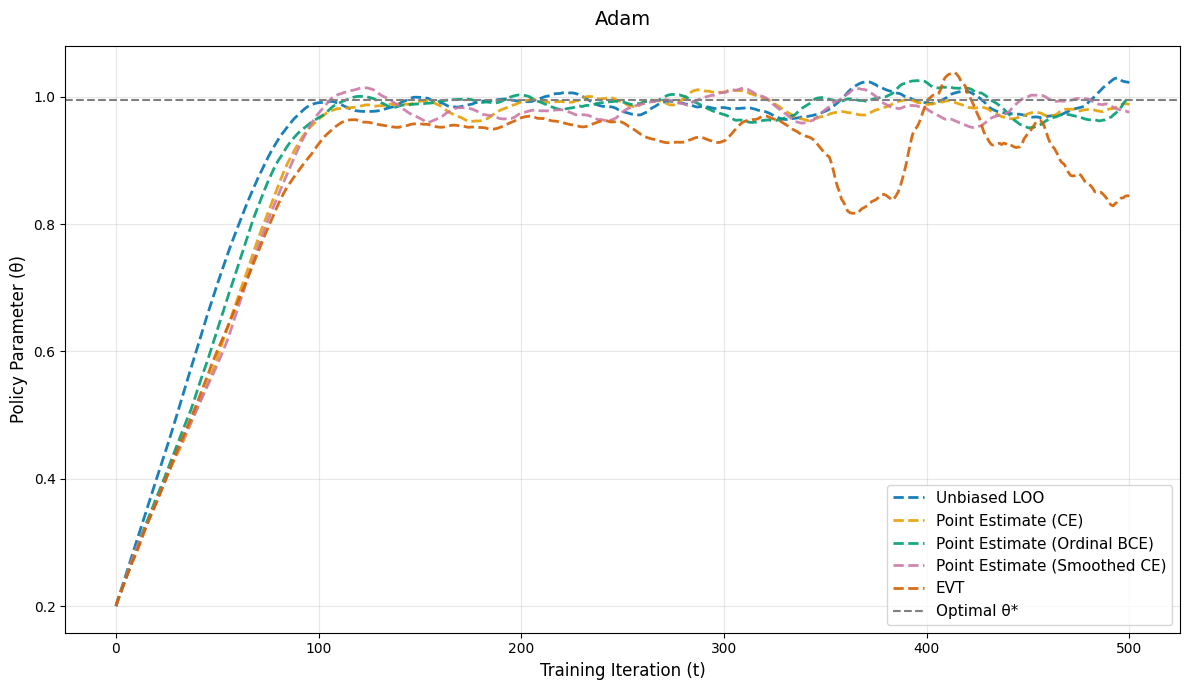

In [21]:
# =====================================================================
# 3. PLOT THE LEARNING CURVES
# =====================================================================
TRAJECTORY_SMOOTH_WINDOW = 25  # centered moving average; 1 = raw (match metrics cell)


# Okabe-Ito-style palette: colorblind-safe, spaced across hues (not the earlier `colors` from pass@k curves)
_line_colors = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # bluish green
    "#CC79A7",  # red-purple
    "#D55E00",  # vermillion
    "#56B4E9",  # sky blue
    "#000000",  # black
    "#F0E442",  # yellow
    "#A65628",  # brown
]
plt.figure(figsize=(12, 7))

for idx, method in enumerate(thetas.keys()):
    plt.plot(trajectories[method], label=method, alpha=0.9, color=_line_colors[idx], linewidth=2, linestyle='--')

plt.title("Adam", fontsize=14, pad=15)
plt.xlabel("Training Iteration (t)", fontsize=12)
plt.ylabel("Policy Parameter (θ)", fontsize=12)
# plt.ylim(0.8, 1.5)
plt.axhline(k_to_best_theta[k], color='gray', linestyle='--', label='Optimal θ*')

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

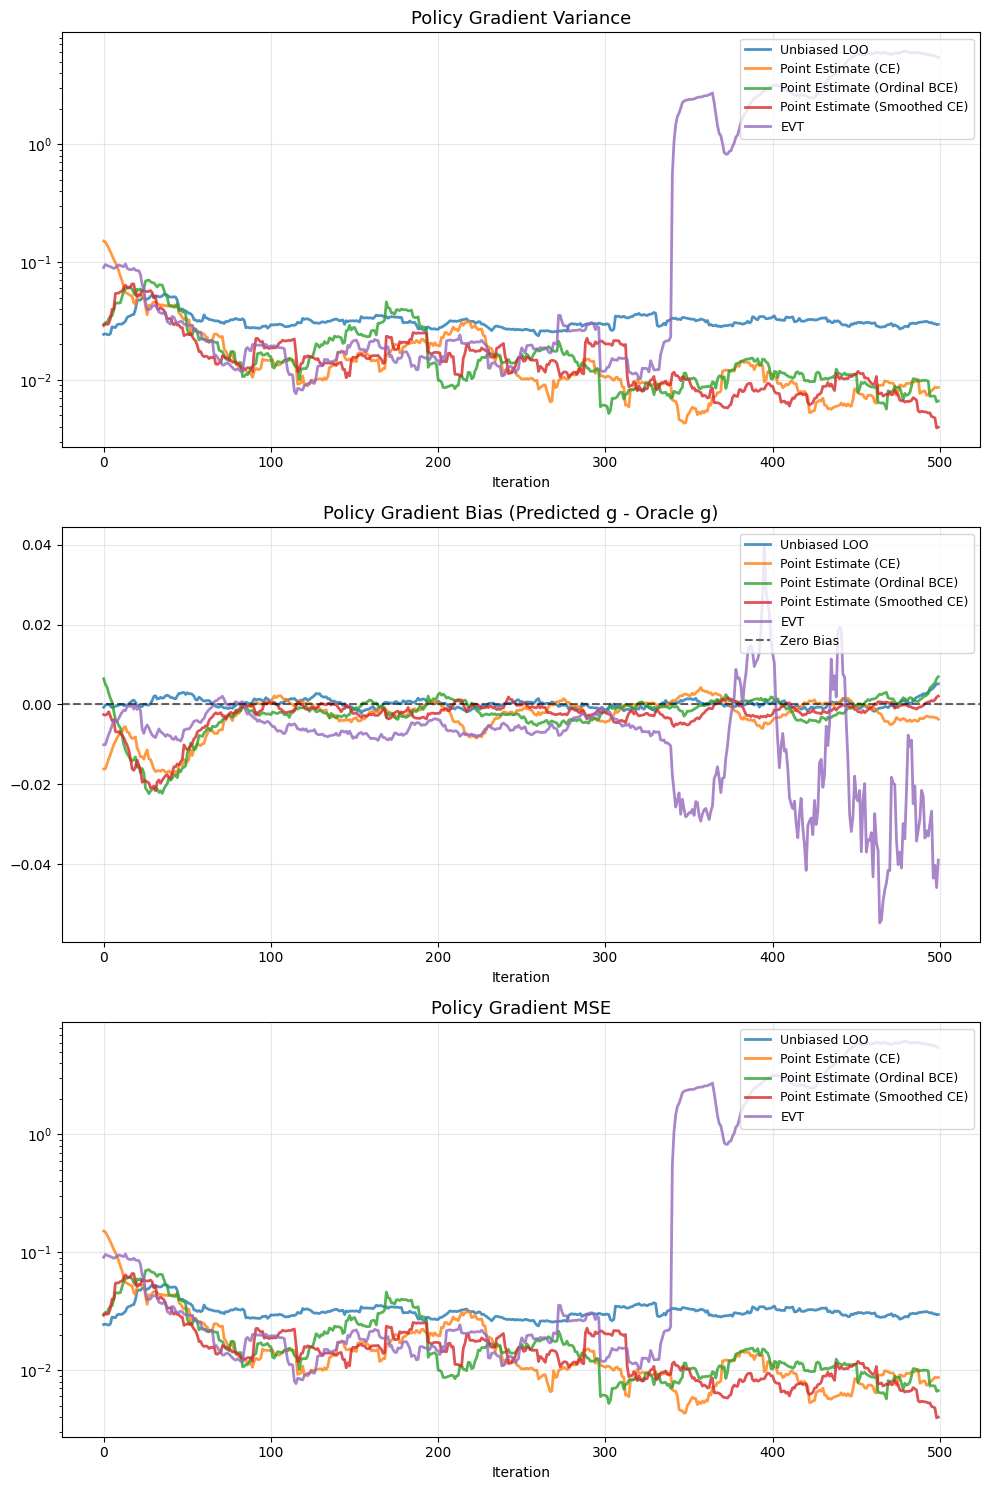


METRICS SUMMARY (Average of final 100 iterations)

--- Policy Gradient Variance ---
  Unbiased LOO                            : 0.031339
  Point Estimate (CE)                     : 0.007985
  Point Estimate (Ordinal BCE)            : 0.009853
  Point Estimate (Smoothed CE)            : 0.007837
  EVT                                     : 4.629706

--- Policy Gradient Bias ---
  Unbiased LOO                            : 0.000050
  Point Estimate (CE)                     : -0.001739
  Point Estimate (Ordinal BCE)            : -0.000602
  Point Estimate (Smoothed CE)            : -0.000572
  EVT                                     : -0.021256

--- Policy Gradient MSE ---
  Unbiased LOO                            : 0.031384
  Point Estimate (CE)                     : 0.008034
  Point Estimate (Ordinal BCE)            : 0.009908
  Point Estimate (Smoothed CE)            : 0.007888
  EVT                                     : 4.651345

--- Advantage Variance (Proxy) ---
  Unbiased LOO       

In [22]:
# =====================================================================
# 5. VISUALIZE AND PRINT INTERNAL METRICS
# =====================================================================
METRIC_SMOOTH_WINDOW = 25  # centered moving average; use 1 for raw trajectories

def _smooth_1d(y, window):
    y = np.asarray(y, dtype=float)
    w = int(window)
    if w <= 1 or len(y) < 3:
        return y
    if w % 2 == 0:
        w += 1
    pad = w // 2
    ypad = np.pad(y, (pad, pad), mode="edge")
    kernel = np.ones(w, dtype=float) / w
    return np.convolve(ypad, kernel, mode="valid")

fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# Plot 1: Gradient Variance
for m, vals in track_g_variance.items():
    # if m == 'EVT':
    #     continue
    axes[0].plot(_smooth_1d(vals, METRIC_SMOOTH_WINDOW), label=m, linewidth=2, alpha=0.8)
axes[0].set_title("Policy Gradient Variance", fontsize=13)
axes[0].set_yscale('log') # Log scale because LOO variance explodes
axes[0].set_xlabel("Iteration")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9, loc='upper right')

# Plot 2: Gradient Bias
for m, vals in track_g_bias.items():
    # if m == 'EVT':
    #     continue
    axes[1].plot(_smooth_1d(vals, METRIC_SMOOTH_WINDOW), label=m, linewidth=2, alpha=0.8)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.6, label='Zero Bias') # Added reference line
axes[1].set_title("Policy Gradient Bias (Predicted g - Oracle g)", fontsize=13)
axes[1].set_xlabel("Iteration")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9, loc='upper right')

# Plot 3: Gradient MSE
for m, vals in track_g_mse.items():
    # if m == 'EVT':
    #     continue
    axes[2].plot(_smooth_1d(vals, METRIC_SMOOTH_WINDOW), label=m, linewidth=2, alpha=0.8)
axes[2].set_title("Policy Gradient MSE", fontsize=13)
axes[2].set_yscale('log') # CRITICAL: Log scale required here too!
axes[2].set_xlabel("Iteration")
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('variance.png')
plt.show()


# =====================================================================
# 6. PRINT SUMMARY FOR LLM CONTEXT
# =====================================================================
print("\n" + "="*65)
print("METRICS SUMMARY (Average of final 100 iterations)")
print("="*65)

# Helper function to print nicely formatted blocks
def print_metric_block(title, tracking_dict):
    print(f"\n--- {title} ---")
    for m, vals in tracking_dict.items():
        if len(vals) > 0:
            avg_val = np.mean(vals[-100:])
            print(f"  {m:<40}: {avg_val:.6f}")

print_metric_block("Policy Gradient Variance", track_g_variance)
print_metric_block("Policy Gradient Bias", track_g_bias)
print_metric_block("Policy Gradient MSE", track_g_mse)
print_metric_block("Advantage Variance (Proxy)", track_adv_var)